Assignment 5

task 1

Given a list of delivery times (in minutes) for 20 Zomato orders, calculate the 25th, 50th, and 75th percentiles using Python's numpy.percentile function.

In [1]:
import numpy as np

delivery_times = [28, 35, 40, 22, 50, 33, 45, 30, 38, 25,
                   60, 42, 29, 33, 48, 27, 55, 31, 39, 44]

q25 = np.percentile(delivery_times, 25)
q50 = np.percentile(delivery_times, 50)
q75 = np.percentile(delivery_times, 75)

print("Delivery times:", delivery_times)
print("25th percentile:", q25)
print("50th percentile (median):", q50)
print("75th percentile:", q75)


Delivery times: [28, 35, 40, 22, 50, 33, 45, 30, 38, 25, 60, 42, 29, 33, 48, 27, 55, 31, 39, 44]
25th percentile: 29.75
50th percentile (median): 36.5
75th percentile: 44.25


**Explanation:** The 25th percentile (29.75 min) means 25% of orders were delivered faster than this. The 50th percentile (36.5 min) is the median delivery time — half the orders arrive before this and half after. The 75th percentile (44.25 min) shows that 75% of deliveries were completed within this time, with only the slowest 25% taking longer. Together these three values give a quick sense of the typical delivery experience without needing to look at every single order.

task 2

Create a Python script that takes an array of IPL player scores and divides them into quartiles using numpy.quantile. Print the values for Q1, Q2 (median), and Q3.

In [2]:
import numpy as np

ipl_scores = [45, 78, 102, 12, 89, 34, 56, 67, 23, 91, 5, 76, 88, 40, 61]

Q1 = np.quantile(ipl_scores, 0.25)
Q2 = np.quantile(ipl_scores, 0.50)
Q3 = np.quantile(ipl_scores, 0.75)

print("IPL scores:", ipl_scores)
print("Q1 (25%):", Q1)
print("Q2 (50% / median):", Q2)
print("Q3 (75%):", Q3)


IPL scores: [45, 78, 102, 12, 89, 34, 56, 67, 23, 91, 5, 76, 88, 40, 61]
Q1 (25%): 37.0
Q2 (50% / median): 61.0
Q3 (75%): 83.0


**Explanation:** Q1 = 37 means a quarter of the innings scored 37 runs or fewer — these are the low-scoring games. Q2 = 61 is the median score, splitting the data into two equal halves. Q3 = 83 means the top quarter of innings scored above this. The gap between Q1 and Q3 shows how spread out the player's performance is — a bigger gap means more inconsistent scoring from match to match.

task 3

Given a list of daily step counts from your fitness app for one month, calculate the Interquartile Range (IQR) in Python and explain what it tells you about your activity consistency.

**Hint:** IQR = Q3 - Q1

In [3]:
import numpy as np

steps = [8500, 9200, 7800, 10200, 6300, 8900, 9500, 7200, 8800, 9100,
         6800, 10500, 7900, 8600, 9300, 7500, 8100, 9800, 7000, 8400,
         9600, 7300, 8700, 10100, 6900, 9000, 8300, 7600, 9400, 8000]

Q1 = np.percentile(steps, 25)
Q3 = np.percentile(steps, 75)
IQR = Q3 - Q1

print("Number of days:", len(steps))
print("Q1:", Q1, " Q3:", Q3)
print("IQR:", IQR)


Number of days: 30
Q1: 7650.0  Q3: 9275.0
IQR: 1625.0


**Explanation:** The middle 50% of the daily step counts (from Q1 = 7650 to Q3 = 9275) span an IQR of 1625 steps. Since the IQR ignores the extreme highest and lowest days, it gives a cleaner picture of "typical" variation than the full range would. An IQR of ~1625 on a base of roughly 8000–9000 steps is moderate — the activity level isn't perfectly fixed day to day, but it also isn't wildly erratic; there's a reasonably consistent routine with some natural day-to-day fluctuation.

task 4

Write a Python function to detect outliers in a list of Swiggy order amounts using the IQR method (any value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR). Print the outlier values.

In [4]:
import numpy as np

def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = [x for x in data if x < lower_bound or x > upper_bound]
    return outliers, lower_bound, upper_bound

swiggy_orders = [250, 320, 280, 300, 270, 310, 290, 260, 1200, 330, 275, 50]

outliers, lower_bound, upper_bound = detect_outliers_iqr(swiggy_orders)

print("Order amounts:", swiggy_orders)
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print("Outliers detected:", outliers)


Order amounts: [250, 320, 280, 300, 270, 310, 290, 260, 1200, 330, 275, 50]
Lower bound: 200.0, Upper bound: 380.0
Outliers detected: [1200, 50]


**Explanation:** Most Swiggy orders here cluster between ₹250–330, so the IQR method sets "normal" bounds at roughly ₹200 to ₹380. Anything outside that range gets flagged — in this case, ₹1200 (an unusually large order, maybe a group order or a splurge) and ₹50 (an unusually small order, maybe just a snack or beverage) are both flagged as outliers. This method is useful because it adapts to the data's own spread instead of using a fixed cutoff.

task 5

Using matplotlib, create a boxplot of your weekly screen time (in hours) for the past 8 weeks. Label the axes and highlight any outliers.

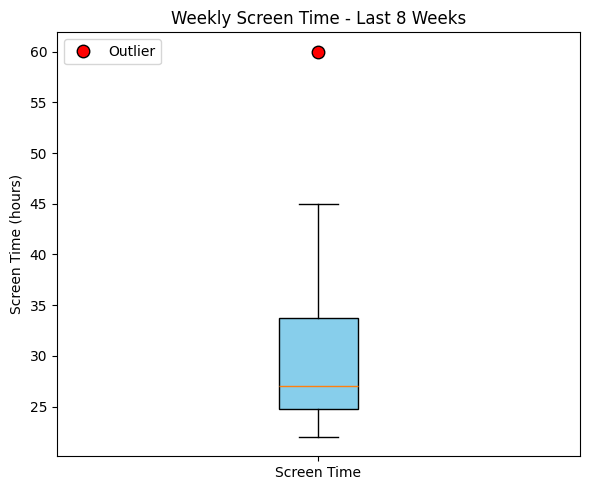

Outlier weeks (hours): [60]


In [5]:
import matplotlib.pyplot as plt
import numpy as np

screen_time = [22, 25, 30, 45, 28, 26, 24, 60]  # hours per week, last 8 weeks

fig, ax = plt.subplots(figsize=(6, 5))
box = ax.boxplot(screen_time, vert=True, patch_artist=True,
                  flierprops=dict(marker='o', markerfacecolor='red', markersize=9,
                                   markeredgecolor='black', label='Outlier'))

for patch in box['boxes']:
    patch.set_facecolor('skyblue')

ax.set_title("Weekly Screen Time - Last 8 Weeks")
ax.set_ylabel("Screen Time (hours)")
ax.set_xticklabels(["Screen Time"])
ax.legend(handles=[box['fliers'][0]], loc='upper left')

plt.tight_layout()
plt.show()

Q1 = np.percentile(screen_time, 25)
Q3 = np.percentile(screen_time, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = [x for x in screen_time if x < lower_bound or x > upper_bound]
print("Outlier weeks (hours):", outliers)


**Explanation:** The box shows where the middle 50% of weekly screen time falls (roughly 24.75 to 33.75 hours), with the line inside marking the median week. The red dot marks 60 hours as an outlier — a week where screen time spiked well above the usual pattern, likely due to something unusual like binge-watching, remote work, or an exam-prep week spent online. The rest of the weeks stay fairly close together, showing a mostly steady weekly screen time habit.